# 02 — Input bit-depth sweep (PyTorch)

Sweeps input quantization in [0,2,4,8] with fixed network precision.

In [1]:
from pathlib import Path
import sys, os

# ---- Path setup (adjust if your repo layout differs) ----
PROJECT_ROOT = Path("..").resolve()
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

In [2]:
import pandas as pd

from config import ExperimentConfig, with_overrides
from runner import run_experiment
from utils import load_runs, flatten_runs
from plots import (
    plot_metric_vs_input_bits,
    plot_delta_from_baseline,
    plot_tradeoff_with_pareto,
)

pd.set_option("display.max_columns", 200)


In [ ]:

base = ExperimentConfig(
    backend="pytorch",
    device="cuda",
    batch_size=256,
    model_precision="fp32",      
    input_quant_bits=0,        
    seed=42,
)

in_bits_list = [0, 8, 4, 2, 1] 

cfgs = [with_overrides(base, input_quant_bits=b) for b in in_bits_list]

# cfgs += [with_overrides(base, model_precision="fp16", input_quant_bits=b) for b in in_bits_list]

In [4]:
records = []
for cfg in cfgs:
    payload, _ = run_experiment(cfg, split="val", save_results_flag=True)
    records.append(payload)

for r in records:
    print(r["run_id"], r["status"], r["results"].get("top1_acc"))

Evaluating on 195 batches...
  Batch [10/195] Top-1: 78.52% | Top-5: 93.16% | Infer: 177.94 ms/batch
  Batch [20/195] Top-1: 76.66% | Top-5: 92.68% | Infer: 136.73 ms/batch
  Batch [30/195] Top-1: 77.93% | Top-5: 92.85% | Infer: 123.31 ms/batch
  Batch [40/195] Top-1: 76.23% | Top-5: 92.95% | Infer: 116.34 ms/batch
  Batch [50/195] Top-1: 75.80% | Top-5: 93.20% | Infer: 112.17 ms/batch
  Batch [60/195] Top-1: 75.70% | Top-5: 93.38% | Infer: 109.40 ms/batch
  Batch [70/195] Top-1: 76.21% | Top-5: 93.53% | Infer: 107.42 ms/batch
  Batch [80/195] Top-1: 76.14% | Top-5: 93.37% | Infer: 105.94 ms/batch
  Batch [90/195] Top-1: 74.97% | Top-5: 92.59% | Infer: 104.87 ms/batch
  Batch [100/195] Top-1: 73.58% | Top-5: 91.71% | Infer: 103.93 ms/batch
  Batch [110/195] Top-1: 72.93% | Top-5: 91.26% | Infer: 103.33 ms/batch
  Batch [120/195] Top-1: 72.68% | Top-5: 90.92% | Infer: 102.69 ms/batch
  Batch [130/195] Top-1: 71.64% | Top-5: 90.37% | Infer: 102.13 ms/batch
  Batch [140/195] Top-1: 71.31%

In [5]:
runs = load_runs("./runs", status="ok")
rows = flatten_runs(runs)
df = pd.DataFrame(rows)

# Filter only what this notebook is responsible for
df_sweep = df[
    (df["cfg.backend"] == "pytorch")
    & (df["cfg.device"] == "cuda")
    & (df["cfg.model_precision"].isin(["fp32"]))   # include "fp16" if you enabled it
    & (df["cfg.input_quant_bits"].isin([0, 8, 4, 2, 1]))
].copy()

df_sweep[[
    "run_id",
    "cfg.model_precision",
    "cfg.input_quant_bits",
    "res.top1_acc",
    "res.top5_acc",
    "res.infer_ms_avg",
    "res.throughput_infer_sps",
    "res.total_samples",
]].sort_values(["cfg.model_precision", "cfg.input_quant_bits"])

,run_id,cfg.model_precision,cfg.input_quant_bits,res.top1_acc,res.top5_acc,res.infer_ms_avg,res.throughput_infer_sps,res.total_samples
2,resnet18_pytorch_fp32_in0b_cuda_bs256,fp32,0,69.799679,89.100561,99.938849,2561.566412,49920
3,resnet18_pytorch_fp32_in1b_cuda_bs256,fp32,1,4.969952,11.588542,95.543882,2679.397090,49920
4,resnet18_pytorch_fp32_in2b_cuda_bs256,fp32,2,31.270032,52.688301,95.580245,2678.377727,49920
5,resnet18_pytorch_fp32_in4b_cuda_bs256,fp32,4,67.009215,87.367788,95.510222,2680.341390,49920
6,resnet18_pytorch_fp32_in8b_cuda_bs256,fp32,8,69.799679,89.100561,95.709096,2674.771906,49920


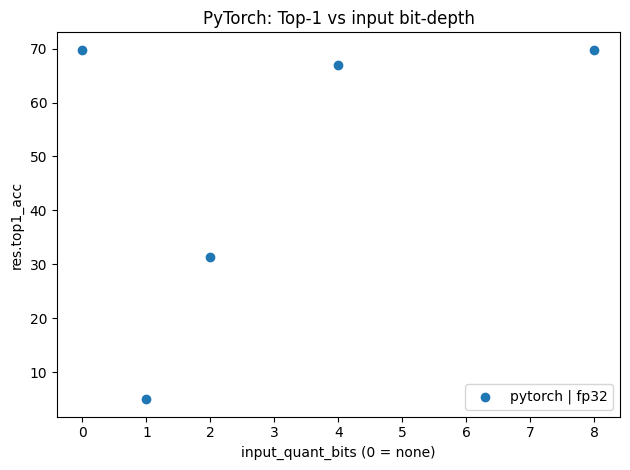

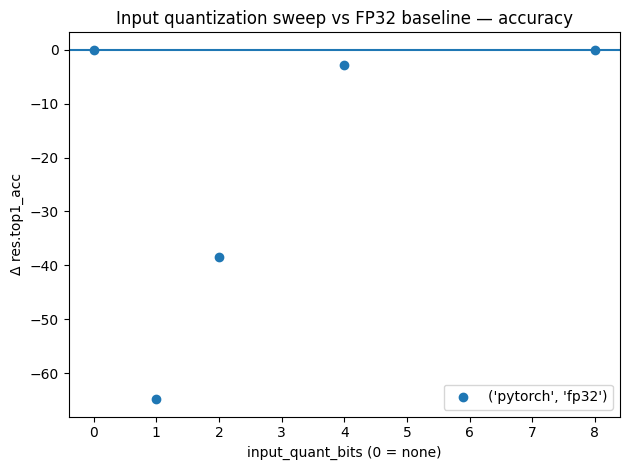

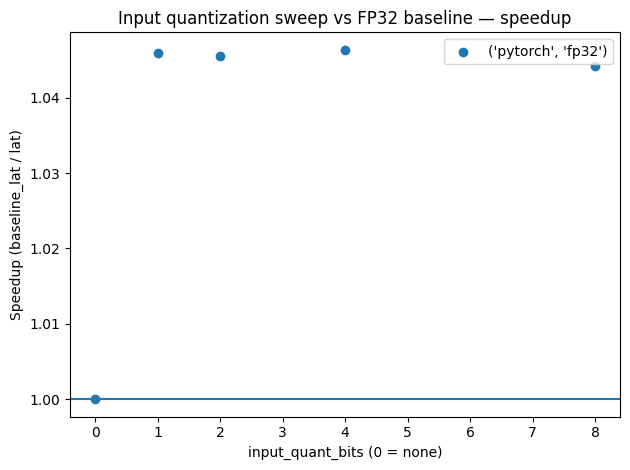

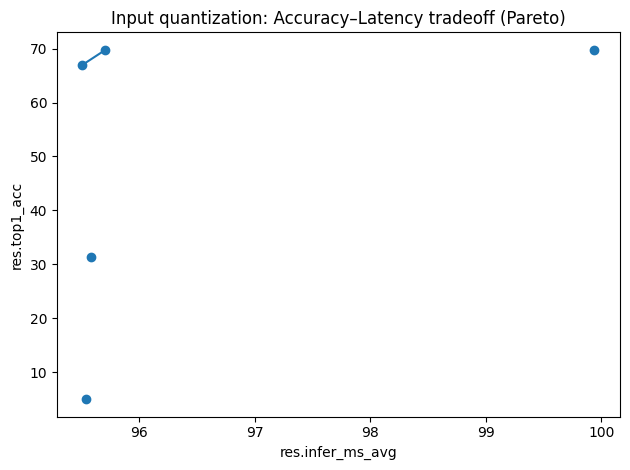

In [6]:
rows_sweep = df_sweep.to_dict(orient="records")

plot_metric_vs_input_bits(
    rows_sweep,
    metric_key="res.top1_acc",
    title="PyTorch: Top-1 vs input bit-depth",
    connect_points=False,
)

plot_delta_from_baseline(
    rows_sweep,
    baseline_selector={
        "cfg.backend": "pytorch",
        "cfg.model_precision": "fp32",
        "cfg.input_quant_bits": 0,
        "cfg.device": "cuda",
    },
    title="Input quantization sweep vs FP32 baseline",
)

plot_tradeoff_with_pareto(
    rows_sweep,
    x_key="res.infer_ms_avg",
    y_key="res.top1_acc",
    title="Input quantization: Accuracy–Latency tradeoff (Pareto)",
)